### Importações

In [1]:
#Importação de pacotes
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np
import joblib # Utilizado para salvar o modelo preditivo
from sklearn.preprocessing import LabelEncoder #Utilizada para fazer o OneHotEncoding
from sklearn.metrics import mean_squared_error,precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix
from imblearn import under_sampling, over_sampling #Utilizada para fazer o balanceamento de dados
from imblearn.over_sampling import SMOTE #Utilizada para fazer o balanceamento de dados
from sklearn.preprocessing import MinMaxScaler #Utilizada para fazer a padronização dos dados
from sklearn.metrics import r2_score # Utilizado para medir a acuracia do modelo preditivo
import pymssql as sql #conexão SQL

warnings.filterwarnings("ignore") 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
#pd.options.display.float_format = '{:.2f}'.format

### Conexão com o banco de dados

In [ ]:
# Cria a conexão com o SQL Server passando os parametros (Servidor, Usuário, Senha, Database)
conexao = sql.connect('localhost', 'python', 'sql1234', 'CLONE_SISTEMA_BANCO')

# Chama a consulta ao banco de dados passando os parametros da conexão criada
df_original = pd.read_sql_query('select * from EXTRACAO_DADOS_SISTEMA', conexao)

# Fecha conexão com banco de dados
conexao.close()

### Analise Exploratória

In [3]:
#Tamanho do conjunto de dados. 
df_original.shape

(10415, 20)

In [4]:
#Visão geral do conjunto de dados
df_original.head(5)

,NUMERO_CONTRATO,DATA_ASSINATURA_CONTRATO,TIPO_FINANCIAMENTO,TAXA_AO_ANO,PZ_FINANCIAMENTO,CIDADE_CLIENTE,ESTADO_CLIENTE,RENDA_MENSAL_CLIENTE,QT_PC_ATRASO,QT_DIAS_PRIM_PC_ATRASO,QT_TOTAL_PC_PAGAS,VL_TOTAL_PC_PAGAS,QT_PC_PAGA_EM_DIA,QT_DIAS_MIN_ATRASO,QT_DIAS_MAX_ATRASO,QT_DIAS_MEDIA_ATRASO,VALOR_FINANCIAMENTO,VALOR_PARCELA,IDADE_DATA_ASSINATURA_CONTRATO,INADIMPLENTE_COBRANCA
0,41637,2012-03-23,IMOBILIARIO,15.0,180,FORTALEZA,CE,4800.0,0,0,97,120078.00,72,3,506,152,73767.0,471.29,70.0,SIM
1,67958,2012-01-24,IMOBILIARIO,15.0,200,SAO PAULO,SP,6800.0,0,0,103,156759.47,42,1,349,93,323251.0,1858.69,28.0,SIM
2,68502,2014-05-23,IMOBILIARIO,18.0,200,SAO PAULO,SP,6800.0,0,0,98,277125.05,83,1,151,39,529419.0,3123.57,60.0,SIM
3,68731,2015-10-23,IMOBILIARIO,15.0,200,SAO PAULO,SP,6800.0,0,0,87,351395.19,66,1,3797,206,499753.0,2873.58,41.0,SIM
4,68996,2017-01-24,IMOBILIARIO,17.0,200,SAO PAULO,SP,6800.0,0,0,71,344249.83,57,1,36,10,722057.0,4224.03,63.0,SIM


In [ ]:
# Analisando os dados missing podemos constatar o seguinte:

df_original.isnull().sum()

NUMERO_CONTRATO                   0
DATA_ASSINATURA_CONTRATO          0
TIPO_FINANCIAMENTO                0
TAXA_AO_ANO                       0
PZ_FINANCIAMENTO                  0
CIDADE_CLIENTE                    0
ESTADO_CLIENTE                    0
RENDA_MENSAL_CLIENTE              0
QT_PC_ATRASO                      0
QT_DIAS_PRIM_PC_ATRASO            0
QT_TOTAL_PC_PAGAS                 0
VL_TOTAL_PC_PAGAS                 4
QT_PC_PAGA_EM_DIA                 0
QT_DIAS_MIN_ATRASO                0
QT_DIAS_MAX_ATRASO                0
QT_DIAS_MEDIA_ATRASO              0
VALOR_FINANCIAMENTO               0
VALOR_PARCELA                     0
IDADE_DATA_ASSINATURA_CONTRATO    1
INADIMPLENTE_COBRANCA             0
dtype: int64

In [6]:
#Informações básicas sobre tipos de variáveis
df_original.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 10415 entries, 0 to 10414
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   NUMERO_CONTRATO                 10415 non-null  int64  
 1   DATA_ASSINATURA_CONTRATO        10415 non-null  object 
 2   TIPO_FINANCIAMENTO              10415 non-null  str    
 3   TAXA_AO_ANO                     10415 non-null  float64
 4   PZ_FINANCIAMENTO                10415 non-null  int64  
 5   CIDADE_CLIENTE                  10415 non-null  str    
 6   ESTADO_CLIENTE                  10415 non-null  str    
 7   RENDA_MENSAL_CLIENTE            10415 non-null  float64
 8   QT_PC_ATRASO                    10415 non-null  int64  
 9   QT_DIAS_PRIM_PC_ATRASO          10415 non-null  int64  
 10  QT_TOTAL_PC_PAGAS               10415 non-null  int64  
 11  VL_TOTAL_PC_PAGAS               10411 non-null  float64
 12  QT_PC_PAGA_EM_DIA               10415 non-n

In [7]:
# Avaliar o período dos dados coletados
inicio = pd.to_datetime(df_original['DATA_ASSINATURA_CONTRATO']).dt.date.min()
fim = pd.to_datetime(df_original['DATA_ASSINATURA_CONTRATO']).dt.date.max()
print('Período dos dados - De:', inicio, 'Até:',fim)

Período dos dados - De: 2012-01-10 Até: 2022-11-14


In [ ]:
# Total de valores únicos de cada variável

valores_unicos = []
for i in df_original.columns[0:20].tolist():
    print(i, ':', len(df_original[i].astype(str).value_counts()))
    valores_unicos.append(len(df_original[i].astype(str).value_counts()))

NUMERO_CONTRATO : 10415
DATA_ASSINATURA_CONTRATO : 1070
TIPO_FINANCIAMENTO : 1
TAXA_AO_ANO : 111
PZ_FINANCIAMENTO : 9
CIDADE_CLIENTE : 525
ESTADO_CLIENTE : 27
RENDA_MENSAL_CLIENTE : 7
QT_PC_ATRASO : 130
QT_DIAS_PRIM_PC_ATRASO : 227
QT_TOTAL_PC_PAGAS : 137
VL_TOTAL_PC_PAGAS : 9860
QT_PC_PAGA_EM_DIA : 129
QT_DIAS_MIN_ATRASO : 122
QT_DIAS_MAX_ATRASO : 534
QT_DIAS_MEDIA_ATRASO : 323
VALOR_FINANCIAMENTO : 834
VALOR_PARCELA : 1826
IDADE_DATA_ASSINATURA_CONTRATO : 78
INADIMPLENTE_COBRANCA : 2


In [9]:
# Visualizando algumas medidas estatisticas
df_original.describe()

,NUMERO_CONTRATO,TAXA_AO_ANO,PZ_FINANCIAMENTO,RENDA_MENSAL_CLIENTE,QT_PC_ATRASO,QT_DIAS_PRIM_PC_ATRASO,QT_TOTAL_PC_PAGAS,VL_TOTAL_PC_PAGAS,QT_PC_PAGA_EM_DIA,QT_DIAS_MIN_ATRASO,QT_DIAS_MAX_ATRASO,QT_DIAS_MEDIA_ATRASO,VALOR_FINANCIAMENTO,VALOR_PARCELA,IDADE_DATA_ASSINATURA_CONTRATO
count,10415.000000,10415.000000,10415.000000,10415.000000,10415.000000,10415.000000,10415.000000,10411.000000,10415.000000,10415.000000,10415.000000,10415.000000,1.041500e+04,10415.000000,10414.000000
mean,95569.356889,17.271483,114.242535,5620.259241,16.716179,664.389438,35.946711,44528.545631,27.667115,6.115699,79.133845,28.841863,3.255909e+05,3617.341097,40.789418
std,34561.658949,2.566596,64.330109,2930.301113,30.706681,1181.352716,28.384415,65640.970502,25.153443,82.908021,334.871089,137.395374,1.774775e+05,1932.714754,12.390906
min,32709.000000,7.000000,48.000000,1800.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,2.932700e+04,185.740000,0.000000
25%,75868.500000,16.000000,72.000000,1800.000000,0.000000,0.000000,11.000000,8675.445000,7.000000,0.000000,0.000000,0.000000,2.100000e+05,2467.755000,31.250000
50%,79111.000000,17.000000,72.000000,7800.000000,0.000000,0.000000,33.000000,24345.600000,22.000000,1.000000,8.000000,4.000000,2.800000e+05,3470.590000,39.000000
75%,136637.500000,19.000000,180.000000,7800.000000,22.000000,1005.500000,54.000000,46787.290000,42.000000,3.000000,62.000000,22.000000,3.929738e+05,4930.245000,49.000000
max,155890.000000,25.500000,240.000000,9800.000000,178.000000,5655.000000,167.000000,714499.740000,136.000000,5465.000000,5710.000000,5480.000000,1.400000e+06,14410.000000,118.000000


In [10]:
print('Maior Valor Financiado:', df_original['VALOR_FINANCIAMENTO'].max())
print('Menor Valor Financiado:', df_original['VALOR_FINANCIAMENTO'].min())

Maior Valor Financiado: 1400000.0
Menor Valor Financiado: 29327.0


In [11]:
# A variavel alvo precisará ser balanceada na etapa de pré-processamento
df_original.groupby(['INADIMPLENTE_COBRANCA']).size()

INADIMPLENTE_COBRANCA
NAO    2377
SIM    8038
dtype: int64

In [12]:
# Aqui não precisaremos alterar nada
df_original.groupby(['PZ_FINANCIAMENTO']).size()

PZ_FINANCIAMENTO
48      343
72     6122
100     939
160       2
180     765
194       2
200     558
220     774
240     910
dtype: int64

In [13]:
# Aqui não precisaremos fazer nenhum tratamento
df_original.groupby(['RENDA_MENSAL_CLIENTE']).size()

RENDA_MENSAL_CLIENTE
1800.0    3512
3800.0      33
4800.0     416
5800.0    1039
6800.0     130
7800.0    4306
9800.0     979
dtype: int64

In [14]:
# Observe que temos uma variedade muito grande de valor financiado, neste caso devemos criar um range de valores
df_original.groupby(['VALOR_FINANCIAMENTO']).size()

VALOR_FINANCIAMENTO
29327.00         1
31421.00         3
39915.00         7
42574.00         7
45396.25         1
45789.00        18
46088.00         1
47574.00         1
55366.00         2
58658.00         1
60991.00         5
65054.00         3
66195.00         1
67439.00         1
67769.00         1
69967.00         3
71559.00        11
72284.00         1
73767.00         9
74050.00         1
75387.00         2
76700.00         2
77743.00         2
78714.00         2
79511.00         1
79706.00         1
80602.00         1
81323.00         4
82688.00         1
83409.00         1
83765.00         1
85303.00         1
85516.00         1
85870.00        15
86581.00         3
86741.00         6
86948.00         1
88748.00         3
92039.00         7
92116.00         2
92673.00         1
93027.00         1
93292.00        15
93378.00         5
95134.00         2
95677.00         1
96569.00         1
97336.00         1
97930.00         1
98949.00         2
99293.00         1
99594.00   

In [ ]:
# Excluindo os registros NA
df_original.dropna(inplace=True)

In [16]:
# Criando faixa de prazos para utilizarmos no modelo preditivo
bins = [-100, 120, 180, 240]
labels = ['Até 120 Meses', '121 até 180 Meses', '181 até 240 Meses']
df_original['FAIXA_PRAZO_FINANCIAMENTO'] = pd.cut(df_original['PZ_FINANCIAMENTO'], bins=bins, labels=labels)
pd.Series.value_counts(df_original.FAIXA_PRAZO_FINANCIAMENTO)

FAIXA_PRAZO_FINANCIAMENTO
Até 120 Meses        7402
181 até 240 Meses    2241
121 até 180 Meses     767
Name: count, dtype: int64

In [17]:
# Criando faixa salarial para utilizarmos no modelo preditivo
bins = [-100, 100000, 200000, 300000, 400000, 500000, 750000, 1000000, 9000000000]
labels = ['Até 100 mil', '101 até 200 mil', '201 até 300 mil', '301 até 400 mil', '401 até 500 mil', 
          '501 até 750 mil', 'De 751 até 1.000.000','Mais de 1.000.000']
df_original['FAIXA_VALOR_FINANCIADO'] = pd.cut(df_original['VALOR_FINANCIAMENTO'], bins=bins, labels=labels)
pd.Series.value_counts(df_original.FAIXA_VALOR_FINANCIADO)

FAIXA_VALOR_FINANCIADO
201 até 300 mil         3949
301 até 400 mil         2098
101 até 200 mil         1823
401 até 500 mil         1128
501 até 750 mil          915
De 751 até 1.000.000     236
Até 100 mil              167
Mais de 1.000.000         94
Name: count, dtype: int64

In [ ]:
# Seleção de colunas

colunas = ['TAXA_AO_ANO', 'CIDADE_CLIENTE', 'ESTADO_CLIENTE','RENDA_MENSAL_CLIENTE', 
           'QT_PC_ATRASO', 'QT_DIAS_PRIM_PC_ATRASO','QT_TOTAL_PC_PAGAS',
           'VL_TOTAL_PC_PAGAS', 'QT_PC_PAGA_EM_DIA','QT_DIAS_MIN_ATRASO',
           'QT_DIAS_MAX_ATRASO', 'QT_DIAS_MEDIA_ATRASO','VALOR_PARCELA',
           'IDADE_DATA_ASSINATURA_CONTRATO', 'FAIXA_VALOR_FINANCIADO',
           'FAIXA_PRAZO_FINANCIAMENTO','INADIMPLENTE_COBRANCA']

df_dados = pd.DataFrame(df_original, columns=colunas)

In [19]:
df_dados.head()

,TAXA_AO_ANO,CIDADE_CLIENTE,ESTADO_CLIENTE,RENDA_MENSAL_CLIENTE,QT_PC_ATRASO,QT_DIAS_PRIM_PC_ATRASO,QT_TOTAL_PC_PAGAS,VL_TOTAL_PC_PAGAS,QT_PC_PAGA_EM_DIA,QT_DIAS_MIN_ATRASO,QT_DIAS_MAX_ATRASO,QT_DIAS_MEDIA_ATRASO,VALOR_PARCELA,IDADE_DATA_ASSINATURA_CONTRATO,FAIXA_VALOR_FINANCIADO,FAIXA_PRAZO_FINANCIAMENTO,INADIMPLENTE_COBRANCA
0,15.0,FORTALEZA,CE,4800.0,0,0,97,120078.00,72,3,506,152,471.29,70.0,Até 100 mil,121 até 180 Meses,SIM
1,15.0,SAO PAULO,SP,6800.0,0,0,103,156759.47,42,1,349,93,1858.69,28.0,301 até 400 mil,181 até 240 Meses,SIM
2,18.0,SAO PAULO,SP,6800.0,0,0,98,277125.05,83,1,151,39,3123.57,60.0,501 até 750 mil,181 até 240 Meses,SIM
3,15.0,SAO PAULO,SP,6800.0,0,0,87,351395.19,66,1,3797,206,2873.58,41.0,401 até 500 mil,181 até 240 Meses,SIM
4,17.0,SAO PAULO,SP,6800.0,0,0,71,344249.83,57,1,36,10,4224.03,63.0,501 até 750 mil,181 até 240 Meses,SIM


In [20]:
df_dados.shape

(10410, 17)

In [21]:
df_dados.info(verbose = True)

<class 'pandas.DataFrame'>
Index: 10410 entries, 0 to 10414
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   TAXA_AO_ANO                     10410 non-null  float64 
 1   CIDADE_CLIENTE                  10410 non-null  str     
 2   ESTADO_CLIENTE                  10410 non-null  str     
 3   RENDA_MENSAL_CLIENTE            10410 non-null  float64 
 4   QT_PC_ATRASO                    10410 non-null  int64   
 5   QT_DIAS_PRIM_PC_ATRASO          10410 non-null  int64   
 6   QT_TOTAL_PC_PAGAS               10410 non-null  int64   
 7   VL_TOTAL_PC_PAGAS               10410 non-null  float64 
 8   QT_PC_PAGA_EM_DIA               10410 non-null  int64   
 9   QT_DIAS_MIN_ATRASO              10410 non-null  int64   
 10  QT_DIAS_MAX_ATRASO              10410 non-null  int64   
 11  QT_DIAS_MEDIA_ATRASO            10410 non-null  int64   
 12  VALOR_PARCELA                   10

In [22]:
df_dados.isnull().sum()

TAXA_AO_ANO                       0
CIDADE_CLIENTE                    0
ESTADO_CLIENTE                    0
RENDA_MENSAL_CLIENTE              0
QT_PC_ATRASO                      0
QT_DIAS_PRIM_PC_ATRASO            0
QT_TOTAL_PC_PAGAS                 0
VL_TOTAL_PC_PAGAS                 0
QT_PC_PAGA_EM_DIA                 0
QT_DIAS_MIN_ATRASO                0
QT_DIAS_MAX_ATRASO                0
QT_DIAS_MEDIA_ATRASO              0
VALOR_PARCELA                     0
IDADE_DATA_ASSINATURA_CONTRATO    0
FAIXA_VALOR_FINANCIADO            0
FAIXA_PRAZO_FINANCIAMENTO         0
INADIMPLENTE_COBRANCA             0
dtype: int64

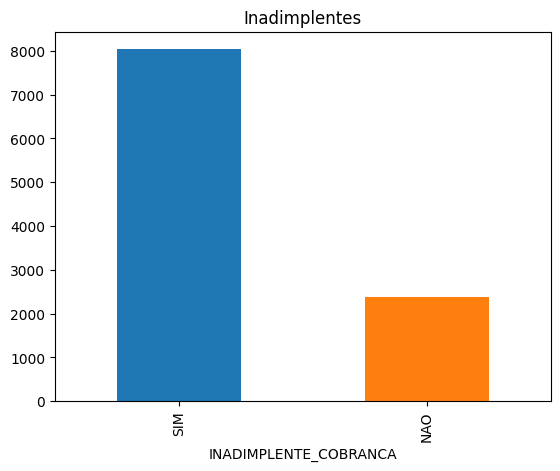

In [ ]:
#Analisando como a variavel alvo está distribuida.

df_dados.INADIMPLENTE_COBRANCA.value_counts().plot(kind='bar', title='Inadimplentes',color = ['#1F77B4', '#FF7F0E']);

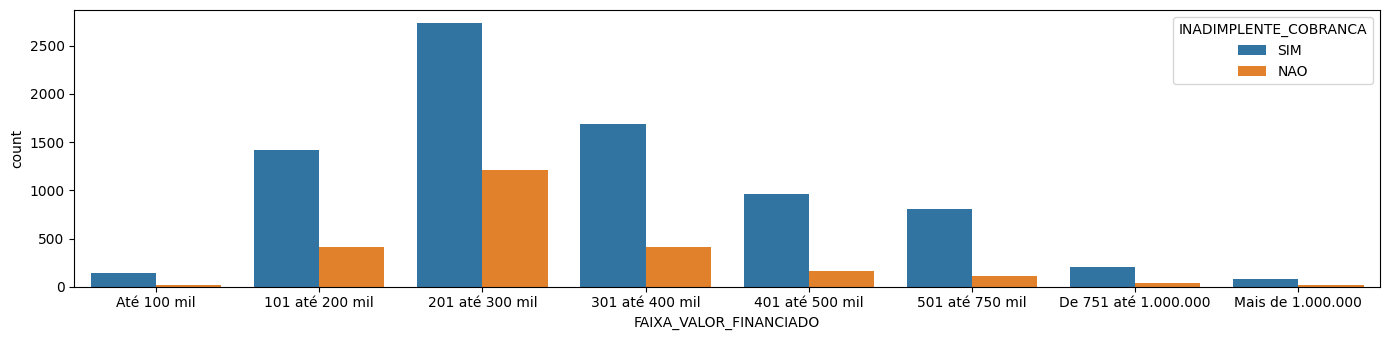

In [24]:
#Podemos constatar na analise que não há discrepancias nestas variaveis

plt.rcParams["figure.figsize"] = [14.00, 3.50]
plt.rcParams["figure.autolayout"] = True
sns.countplot(data = df_dados, x = "FAIXA_VALOR_FINANCIADO", hue = "INADIMPLENTE_COBRANCA")
plt.show()

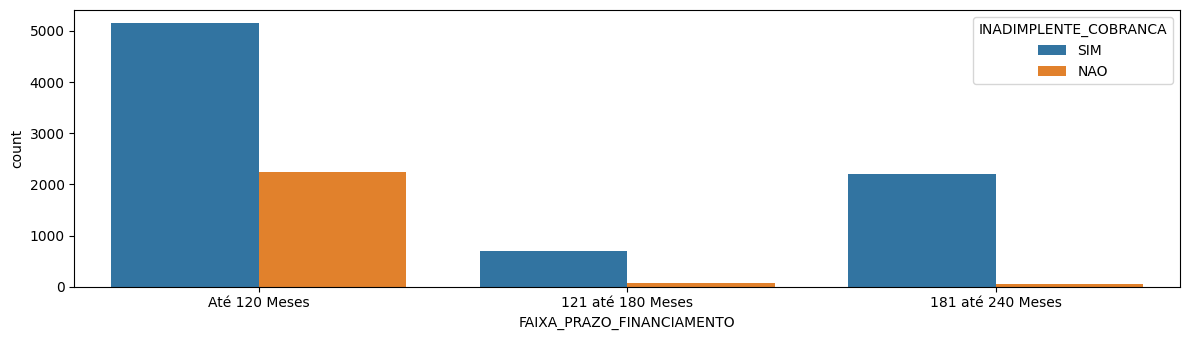

In [25]:
#Podemos constatar na analise que não há discrepancias nestas variaveis

plt.rcParams["figure.figsize"] = [12.00, 3.50]
plt.rcParams["figure.autolayout"] = True
sns.countplot(data = df_dados, x = "FAIXA_PRAZO_FINANCIAMENTO", hue = "INADIMPLENTE_COBRANCA")
plt.show()

In [26]:
df_dados.info()

<class 'pandas.DataFrame'>
Index: 10410 entries, 0 to 10414
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   TAXA_AO_ANO                     10410 non-null  float64 
 1   CIDADE_CLIENTE                  10410 non-null  str     
 2   ESTADO_CLIENTE                  10410 non-null  str     
 3   RENDA_MENSAL_CLIENTE            10410 non-null  float64 
 4   QT_PC_ATRASO                    10410 non-null  int64   
 5   QT_DIAS_PRIM_PC_ATRASO          10410 non-null  int64   
 6   QT_TOTAL_PC_PAGAS               10410 non-null  int64   
 7   VL_TOTAL_PC_PAGAS               10410 non-null  float64 
 8   QT_PC_PAGA_EM_DIA               10410 non-null  int64   
 9   QT_DIAS_MIN_ATRASO              10410 non-null  int64   
 10  QT_DIAS_MAX_ATRASO              10410 non-null  int64   
 11  QT_DIAS_MEDIA_ATRASO            10410 non-null  int64   
 12  VALOR_PARCELA                   10

In [27]:
#carregar variaveis para plot
variaveis_numericas = []
for i in df_dados.columns[0:17].tolist():
        if df_dados.dtypes[i] == 'int64' or df_dados.dtypes[i] == 'float64':                        
            variaveis_numericas.append(i)    

In [28]:
#Visualizando as variáveis numéricas
variaveis_numericas

['TAXA_AO_ANO',
 'RENDA_MENSAL_CLIENTE',
 'QT_PC_ATRASO',
 'QT_DIAS_PRIM_PC_ATRASO',
 'QT_TOTAL_PC_PAGAS',
 'VL_TOTAL_PC_PAGAS',
 'QT_PC_PAGA_EM_DIA',
 'QT_DIAS_MIN_ATRASO',
 'QT_DIAS_MAX_ATRASO',
 'QT_DIAS_MEDIA_ATRASO',
 'VALOR_PARCELA',
 'IDADE_DATA_ASSINATURA_CONTRATO']

In [29]:
#Quantidade de variaveis
len(variaveis_numericas)

12

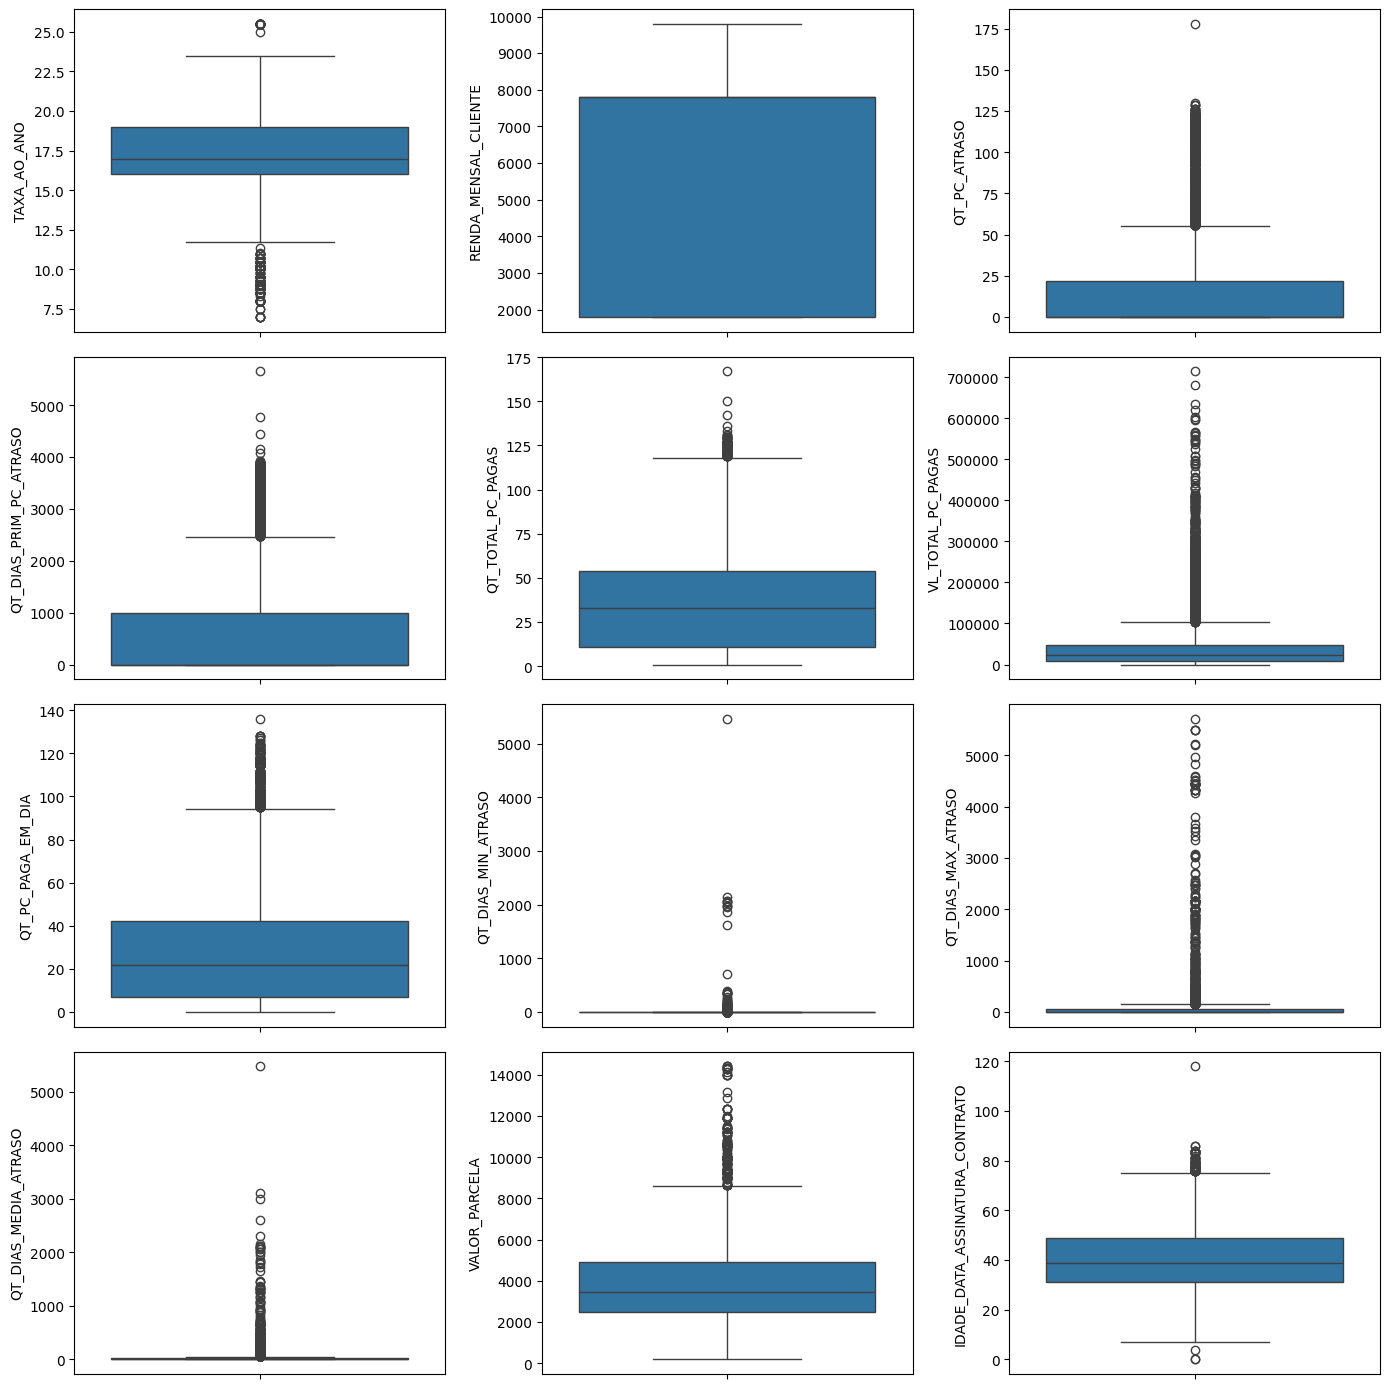

In [30]:
#Podemos observar nos boxplots abaixo que as variáveis númericas apresentam uma grande quantidade de "possíveis" outliers
#Precisamos avaliar cada uma dessas variaveis dentro do contexto dos dados para saber se realmente iremos trata-las como outlier

plt.rcParams["figure.figsize"] = [14.00, 14.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(4, 3) #4 linhas e 3 colunas

linha = 0
coluna = 0
for i in variaveis_numericas:
    sns.boxplot(data = df_dados, y=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 3:
        linha += 1
        coluna = 0            

plt.show()

In [31]:
# carregar variaveis categoricas para OneHotEncoding
# Colocamos o SLICE até 16 porque NÃO precisamos fazer OneHotEncoding para variavel TARGET
variaveis_categoricas = []
for i in df_dados.columns[0:16].tolist():
        if df_dados.dtypes[i] == 'object' or df_dados.dtypes[i] == 'category' or df_dados.dtypes[i] == 'str':                        
            variaveis_categoricas.append(i)    

In [32]:
# Visualizando as variaveis categoricas
variaveis_categoricas

['CIDADE_CLIENTE',
 'ESTADO_CLIENTE',
 'FAIXA_VALOR_FINANCIADO',
 'FAIXA_PRAZO_FINANCIAMENTO']

In [33]:
# Cria o encoder e aplica OneHotEncoder
lb = LabelEncoder()

for var in variaveis_categoricas:
    df_dados[var] = lb.fit_transform(df_dados[var])

In [34]:
df_dados.head()

,TAXA_AO_ANO,CIDADE_CLIENTE,ESTADO_CLIENTE,RENDA_MENSAL_CLIENTE,QT_PC_ATRASO,QT_DIAS_PRIM_PC_ATRASO,QT_TOTAL_PC_PAGAS,VL_TOTAL_PC_PAGAS,QT_PC_PAGA_EM_DIA,QT_DIAS_MIN_ATRASO,QT_DIAS_MAX_ATRASO,QT_DIAS_MEDIA_ATRASO,VALOR_PARCELA,IDADE_DATA_ASSINATURA_CONTRATO,FAIXA_VALOR_FINANCIADO,FAIXA_PRAZO_FINANCIAMENTO,INADIMPLENTE_COBRANCA
0,15.0,152,5,4800.0,0,0,97,120078.00,72,3,506,152,471.29,70.0,5,0,SIM
1,15.0,453,25,6800.0,0,0,103,156759.47,42,1,349,93,1858.69,28.0,2,1,SIM
2,18.0,453,25,6800.0,0,0,98,277125.05,83,1,151,39,3123.57,60.0,4,1,SIM
3,15.0,453,25,6800.0,0,0,87,351395.19,66,1,3797,206,2873.58,41.0,3,1,SIM
4,17.0,453,25,6800.0,0,0,71,344249.83,57,1,36,10,4224.03,63.0,4,1,SIM


In [35]:
# Visualizando os tipos das variaveis
df_dados.info()

<class 'pandas.DataFrame'>
Index: 10410 entries, 0 to 10414
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   TAXA_AO_ANO                     10410 non-null  float64
 1   CIDADE_CLIENTE                  10410 non-null  int64  
 2   ESTADO_CLIENTE                  10410 non-null  int64  
 3   RENDA_MENSAL_CLIENTE            10410 non-null  float64
 4   QT_PC_ATRASO                    10410 non-null  int64  
 5   QT_DIAS_PRIM_PC_ATRASO          10410 non-null  int64  
 6   QT_TOTAL_PC_PAGAS               10410 non-null  int64  
 7   VL_TOTAL_PC_PAGAS               10410 non-null  float64
 8   QT_PC_PAGA_EM_DIA               10410 non-null  int64  
 9   QT_DIAS_MIN_ATRASO              10410 non-null  int64  
 10  QT_DIAS_MAX_ATRASO              10410 non-null  int64  
 11  QT_DIAS_MEDIA_ATRASO            10410 non-null  int64  
 12  VALOR_PARCELA                   10410 non-null  

In [36]:
# Visualiznado a quantidade da variavel target para balanceamento
variavel_target = df_dados.INADIMPLENTE_COBRANCA.value_counts()
variavel_target

INADIMPLENTE_COBRANCA
SIM    8035
NAO    2375
Name: count, dtype: int64

In [ ]:
# 1. Certificar que o TARGET também é numérico (0 e 1)
# O SMOTE precisa que o alvo não seja string
lb_target = LabelEncoder()
df_dados['INADIMPLENTE_COBRANCA'] = lb_target.fit_transform(df_dados['INADIMPLENTE_COBRANCA'])

# 2. Identificar e transformar TODAS as colunas de texto restantes (incluindo Cidade e Estado)
# Usamos select_dtypes para garantir que pegamos qualquer coluna 'object' ou 'string'
variaveis_categoricas = df_dados.iloc[:, 0:16].select_dtypes(include=['object', 'string']).columns.tolist()

lb_feat = LabelEncoder()
for var in variaveis_categoricas:
    df_dados[var] = lb_feat.fit_transform(df_dados[var])

# 3. Separar as variáveis preditoras (colunas de 0 a 15) e o Target (coluna 16)
# Mudamos para 0:16 para incluir a FAIXA_PRAZO_FINANCIAMENTO
PREDITORAS = df_dados.iloc[:, 0:16]  
TARGET = df_dados['INADIMPLENTE_COBRANCA']


seed = 100
balanceador = SMOTE(random_state = seed)

# Aplica o balanceador nos dados 100% numéricos
PREDITORAS_RES, TARGET_RES = balanceador.fit_resample(PREDITORAS, TARGET)

# Verificação
print(f"Shape original: {TARGET.value_counts()}")
print(f"Shape após SMOTE: {TARGET_RES.value_counts()}")

Shape original: INADIMPLENTE_COBRANCA
1    8035
0    2375
Name: count, dtype: int64
Shape após SMOTE: INADIMPLENTE_COBRANCA
1    8035
0    8035
Name: count, dtype: int64


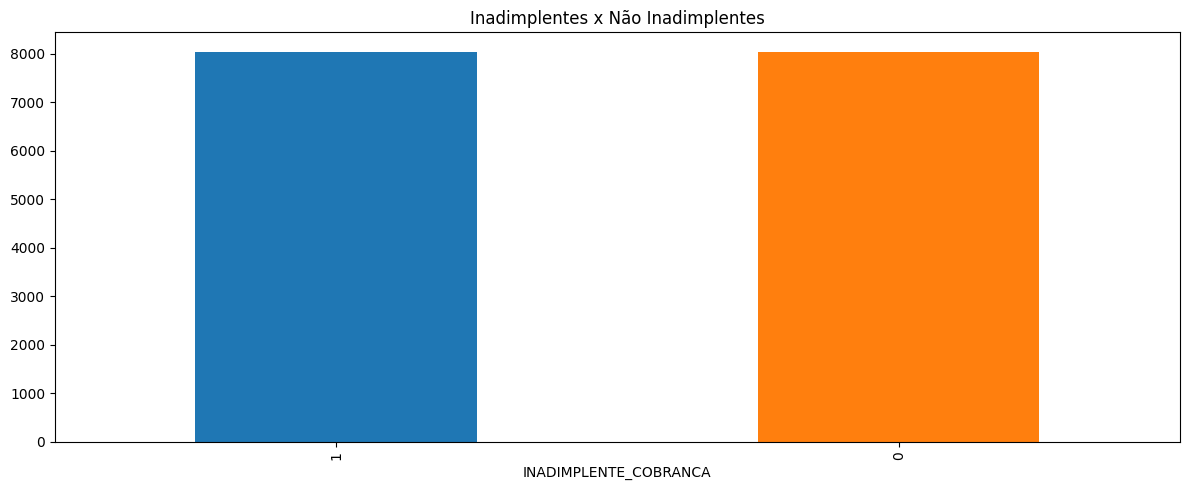

In [38]:
# Visualizando o balanceamento da variável TARGET
plt.rcParams["figure.figsize"] = [12.00, 5.00]
plt.rcParams["figure.autolayout"] = True
TARGET_RES.value_counts().plot(kind='bar', title='Inadimplentes x Não Inadimplentes',color = ['#1F77B4', '#FF7F0E']);

In [39]:
# Quantidade de registros antes do balanceamento
print("Quantidade de registros antes do balanceamento:")
print(PREDITORAS.shape[0])

print("Quantidade de registros depois do balanceamento:")
print(PREDITORAS_RES.shape[0])

print("Quantidade de registros antes do balanceamento:")
print(TARGET.shape[0])

print("Quantidade de registros depois do balanceamento:")
print(TARGET_RES.shape[0])

Quantidade de registros antes do balanceamento:
10410
Quantidade de registros depois do balanceamento:
16070
Quantidade de registros antes do balanceamento:
10410
Quantidade de registros depois do balanceamento:
16070


In [40]:
df_dados.head()

,TAXA_AO_ANO,CIDADE_CLIENTE,ESTADO_CLIENTE,RENDA_MENSAL_CLIENTE,QT_PC_ATRASO,QT_DIAS_PRIM_PC_ATRASO,QT_TOTAL_PC_PAGAS,VL_TOTAL_PC_PAGAS,QT_PC_PAGA_EM_DIA,QT_DIAS_MIN_ATRASO,QT_DIAS_MAX_ATRASO,QT_DIAS_MEDIA_ATRASO,VALOR_PARCELA,IDADE_DATA_ASSINATURA_CONTRATO,FAIXA_VALOR_FINANCIADO,FAIXA_PRAZO_FINANCIAMENTO,INADIMPLENTE_COBRANCA
0,15.0,152,5,4800.0,0,0,97,120078.00,72,3,506,152,471.29,70.0,5,0,1
1,15.0,453,25,6800.0,0,0,103,156759.47,42,1,349,93,1858.69,28.0,2,1,1
2,18.0,453,25,6800.0,0,0,98,277125.05,83,1,151,39,3123.57,60.0,4,1,1
3,15.0,453,25,6800.0,0,0,87,351395.19,66,1,3797,206,2873.58,41.0,3,1,1
4,17.0,453,25,6800.0,0,0,71,344249.83,57,1,36,10,4224.03,63.0,4,1,1


In [41]:
df_dados.info()

<class 'pandas.DataFrame'>
Index: 10410 entries, 0 to 10414
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   TAXA_AO_ANO                     10410 non-null  float64
 1   CIDADE_CLIENTE                  10410 non-null  int64  
 2   ESTADO_CLIENTE                  10410 non-null  int64  
 3   RENDA_MENSAL_CLIENTE            10410 non-null  float64
 4   QT_PC_ATRASO                    10410 non-null  int64  
 5   QT_DIAS_PRIM_PC_ATRASO          10410 non-null  int64  
 6   QT_TOTAL_PC_PAGAS               10410 non-null  int64  
 7   VL_TOTAL_PC_PAGAS               10410 non-null  float64
 8   QT_PC_PAGA_EM_DIA               10410 non-null  int64  
 9   QT_DIAS_MIN_ATRASO              10410 non-null  int64  
 10  QT_DIAS_MAX_ATRASO              10410 non-null  int64  
 11  QT_DIAS_MEDIA_ATRASO            10410 non-null  int64  
 12  VALOR_PARCELA                   10410 non-null  

Treinamento

In [42]:
# Divisão em Dados de Treino e Teste.
X_treino, X_teste, Y_treino, Y_teste = train_test_split(PREDITORAS_RES, TARGET_RES, test_size = 0.3, random_state = 42)

In [43]:
# Normalizando as Variáveis - Pré Processamento dos Dados
Normalizador = MinMaxScaler()
X_treino_normalizados = Normalizador.fit_transform(X_treino)
X_teste_normalizados = Normalizador.transform(X_teste)

In [44]:
# visualizando a dimensão dos dados de treino
X_treino_normalizados.shape

(11249, 16)

In [45]:
# visualizando os dados de treino normalizados
X_treino_normalizados

array([[0.45945946, 0.03816794, 0.15384615, ..., 0.22033898, 0.57142857,
        1.        ],
       [0.66904491, 0.12977099, 0.23076923, ..., 0.41221454, 0.42857143,
        1.        ],
       [0.59459459, 0.3110687 , 0.30769231, ..., 0.25423729, 0.        ,
        0.        ],
       ...,
       [0.10810811, 0.3110687 , 0.30769231, ..., 0.34745763, 0.        ,
        1.        ],
       [0.64864865, 0.86450382, 0.96153846, ..., 0.44444926, 0.14285714,
        1.        ],
       [0.42432432, 0.10305344, 0.38461538, ..., 0.3559322 , 0.        ,
        0.        ]], shape=(11249, 16))

In [46]:
# Criando o classificador com Random Forest
clf = RandomForestClassifier(n_estimators  = 300)

# Construção do modelo
clf = clf.fit(X_treino_normalizados, Y_treino)

In [47]:
# Verificando a acuracia do modelo com dados de teste
scores = clf.score(X_teste_normalizados,Y_teste)
scores

0.9199336237295167

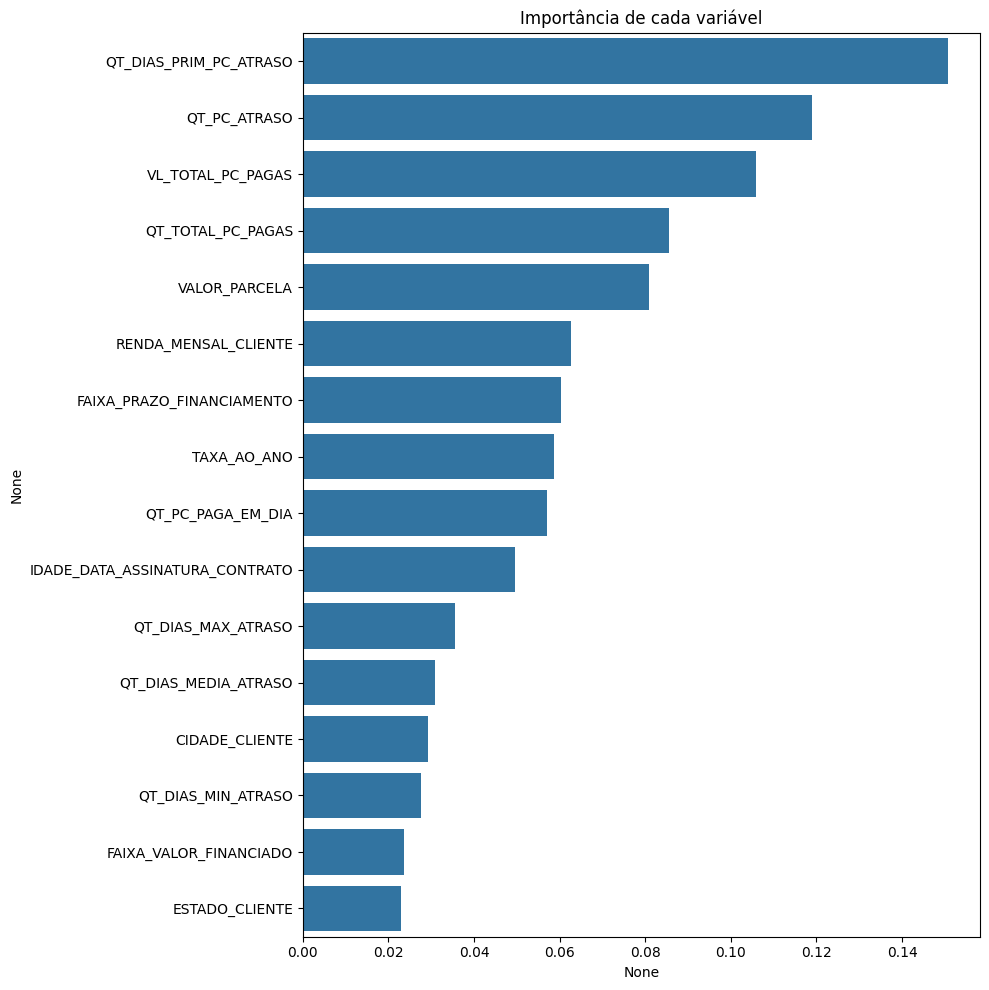

In [48]:
# Exibindo a importancia de cada variavel no modelo preditivo
plt.rcParams["figure.figsize"] = [10.00, 10.00]
plt.rcParams["figure.autolayout"] = True

importances = pd.Series(data=clf.feature_importances_, index=PREDITORAS.columns)
importances = importances.sort_values(ascending = False)
sns.barplot(x=importances, y=importances.index, orient='h').set_title('Importância de cada variável')
plt.show()

In [49]:
importances.sort_values(ascending = False)

QT_DIAS_PRIM_PC_ATRASO            0.150688
QT_PC_ATRASO                      0.118987
VL_TOTAL_PC_PAGAS                 0.105894
QT_TOTAL_PC_PAGAS                 0.085562
VALOR_PARCELA                     0.080787
RENDA_MENSAL_CLIENTE              0.062607
FAIXA_PRAZO_FINANCIAMENTO         0.060273
TAXA_AO_ANO                       0.058715
QT_PC_PAGA_EM_DIA                 0.057030
IDADE_DATA_ASSINATURA_CONTRATO    0.049578
QT_DIAS_MAX_ATRASO                0.035540
QT_DIAS_MEDIA_ATRASO              0.030874
CIDADE_CLIENTE                    0.029330
QT_DIAS_MIN_ATRASO                0.027666
FAIXA_VALOR_FINANCIADO            0.023592
ESTADO_CLIENTE                    0.022878
dtype: float64

In [50]:
# Salvando o modelo criado e treinado
joblib.dump(clf, 'modelo_treinado.pk')

['modelo_treinado.pk']

In [51]:
# Carregando o modelo treinado
clf = joblib.load('modelo_treinado.pk')

In [52]:
#Importação do arquivo de dados

# Cria a conexão com o SQL Server passando os parametros (Servidor, Usuário, Senha, Database)
conexao = sql.connect('localhost', 'python', 'sql1234', 'CLONE_SISTEMA_BANCO')

# Chama a consulta ao banco de dados passando os parametros da conexão criada
df_original = pd.read_sql_query('select * from EXTRACAO_DADOS_SISTEMA', conexao)

# Fecha conexão com banco de dados
conexao.close()

In [ ]:
# PREDITORAS: definição explícita das colunas
colunas_preditoras = [
    'TAXA_AO_ANO', 'CIDADE_CLIENTE', 'ESTADO_CLIENTE', 'RENDA_MENSAL_CLIENTE',
    'QT_PC_ATRASO', 'QT_DIAS_PRIM_PC_ATRASO', 'QT_TOTAL_PC_PAGAS',
    'VL_TOTAL_PC_PAGAS', 'QT_PC_PAGA_EM_DIA', 'QT_DIAS_MIN_ATRASO',
    'QT_DIAS_MAX_ATRASO', 'QT_DIAS_MEDIA_ATRASO', 'VALOR_PARCELA',
    'IDADE_DATA_ASSINATURA_CONTRATO', 'FAIXA_VALOR_FINANCIADO',
    'FAIXA_PRAZO_FINANCIAMENTO'
]

df_dados = pd.DataFrame(df_original, columns=colunas_preditoras + ['INADIMPLENTE_COBRANCA'])

# LABEL ENCODING: detecta categóricas de forma segura
lb = LabelEncoder()

for col in colunas_preditoras:
    if df_dados[col].dtype == 'object' or df_dados[col].dtype.name == 'category':
        df_dados[col] = lb.fit_transform(df_dados[col].astype(str))  # <-- astype(str) é a correção-chave

# Verificação: garante que não sobrou nenhuma coluna não-numérica
colunas_problema = df_dados[colunas_preditoras].select_dtypes(exclude='number').columns.tolist()
if colunas_problema:
    raise ValueError(f"Colunas ainda não numéricas: {colunas_problema}")

# SEPARAÇÃO E NORMALIZAÇÃO
PREDITORAS = df_dados[colunas_preditoras]

Normalizador = MinMaxScaler()
dados_normalizados = Normalizador.fit_transform(PREDITORAS)

# Previsões
previsoes = clf.predict(dados_normalizados)
probabilidades = clf.predict_proba(dados_normalizados)

df_original['PREVISOES'] = previsoes
df_original['PROBABILIDADES'] = probabilidades[:, 1]

df_original.head()

ValueError: could not convert string to float: 'FORTALEZA'